In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import xlabel, ylabel
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1. Data collection

In [3]:
car_dataset = pd.read_csv('CarPrice_Assignment.csv')

In [4]:
car_dataset

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,201,-1,volvo 145e (sw),gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0
201,202,-1,volvo 144ea,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0
202,203,-1,volvo 244dl,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0
203,204,-1,volvo 246,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470.0


In [5]:
selected_columns = ['fueltype', 'curbweight', 'cylindernumber', 'enginesize', 'highwaympg']

'''
fueltype: The type of fuel the car uses (e.g., "gas" or "diesel").
curbweight: The weight of the car without passengers or cargo.
cylindernumber: The number of cylinders in the engine.
enginesize: The size of the car's engine in cubic centimeters.
highwaympg: The car's miles per gallon (mpg) in highway driving conditions.
'''

'\nfueltype: The type of fuel the car uses (e.g., "gas" or "diesel").\ncurbweight: The weight of the car without passengers or cargo.\ncylindernumber: The number of cylinders in the engine.\nenginesize: The size of the car\'s engine in cubic centimeters.\nhighwaympg: The car\'s miles per gallon (mpg) in highway driving conditions.\n'

In [6]:
car_df = car_dataset[selected_columns]
car_df

,fueltype,curbweight,cylindernumber,enginesize,highwaympg
0,gas,2548,four,130,27
1,gas,2548,four,130,27
2,gas,2823,six,152,26
3,gas,2337,four,109,30
4,gas,2824,five,136,22
...,...,...,...,...,...
200,gas,2952,four,141,28
201,gas,3049,four,141,25
202,gas,3012,six,173,23
203,diesel,3217,six,145,27


In [15]:
car_df["fueltype"].unique()

<StringArray>
['gas', 'diesel']
Length: 2, dtype: str

# 2. Analysis of features' relationships with Fuel efficiency

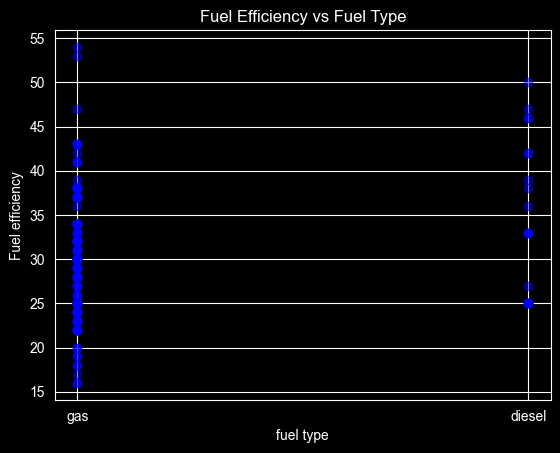

In [7]:
''' Fuel Efficiency vs Fuel Type chart '''

plt.scatter(car_df['fueltype'], car_df['highwaympg'], color= 'blue', alpha=0.5)
plt.xlabel('fuel type')
plt.ylabel('Fuel efficiency')
plt.title('Fuel Efficiency vs Fuel Type')
plt.show()

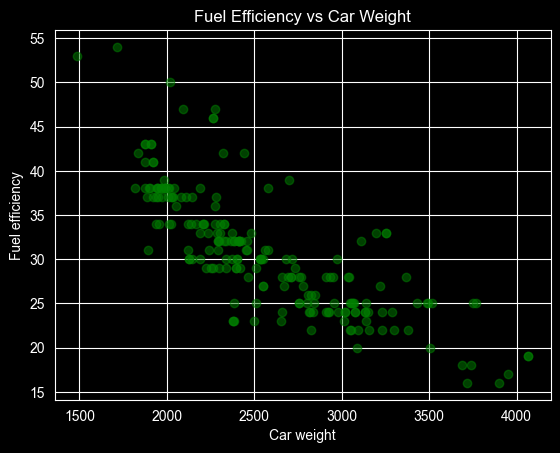

In [8]:
''' Fuel Efficiency vs Car weight chart '''

plt.scatter(car_df['curbweight'], car_df['highwaympg'], color='green', alpha=0.5)
plt.xlabel('Car weight')
plt.ylabel('Highway mpg')
plt.ylabel('Fuel efficiency')
plt.title('Fuel Efficiency vs Car Weight')
plt.show()

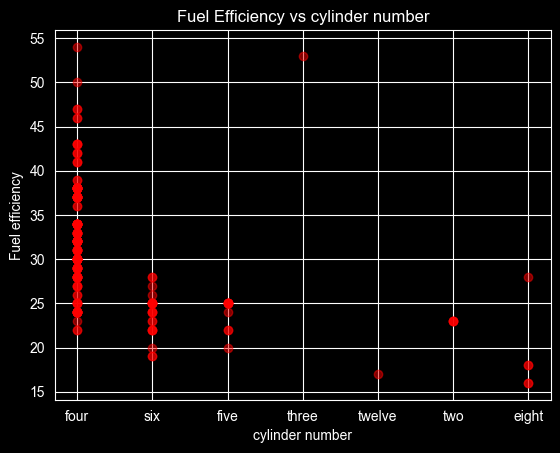

In [9]:
''' Fuel Efficiency vs cylinder number chart '''

plt.scatter(car_df['cylindernumber'], car_df['highwaympg'], color='red', alpha=0.5)
plt.xlabel('cylinder number')
plt.ylabel('Fuel efficiency')
plt.title('Fuel Efficiency vs cylinder number')
plt.show()

# 3.Preparing the data

In [18]:
'''
 my dataset has two columns with string data type
 the model can't understand it
 for that i convert it to numeric data
'''

cylindernumber_mapping = {'four': 4, 'six': 6, 'five': 5, 'three': 3, 'twelve': 12, 'two': 2, 'eight': 8}
fueltype_mapping = {'gas': 0, 'diesel': 1}

car_df["cylindernumber_map"] = car_df["cylindernumber"].map(cylindernumber_mapping)
car_df["fueltype_map"] = car_df['fueltype'].map(fueltype_mapping)

X = car_df[['fueltype_map', 'curbweight', 'cylindernumber_map', 'enginesize']]
Y = car_df['highwaympg']

In [19]:
X

,fueltype_map,curbweight,cylindernumber_map,enginesize
0,0,2548,4,130
1,0,2548,4,130
2,0,2823,6,152
3,0,2337,4,109
4,0,2824,5,136
...,...,...,...,...
200,0,2952,4,141
201,0,3049,4,141
202,0,3012,6,173
203,1,3217,6,145


In [20]:
Y

0      27
1      27
2      26
3      30
4      22
       ..
200    28
201    25
202    23
203    27
204    25
Name: highwaympg, Length: 205, dtype: int64

In [21]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y , test_size=0.2, random_state=42)

# 4. Train the model

In [22]:
model = LinearRegression()
model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


# 5. make prediction

In [26]:
Y_pred = model.predict(X_test)
for actual, predict in list(zip(Y_test[:10], Y_pred[:10])):
    print(f"Actual: {round(actual,2)} | Predicted: {round(predict, 2)}")

Actual:  22 | Predicted: 22.9
Actual:  22 | Predicted: 24.38
Actual:  34 | Predicted: 32.47
Actual:  28 | Predicted: 28.31
Actual:  25 | Predicted: 25.06
Actual:  37 | Predicted: 35.7
Actual:  47 | Predicted: 41.68
Actual:  34 | Predicted: 34.39
Actual:  31 | Predicted: 30.7
Actual:  46 | Predicted: 41.86
**********
MSE: 15.022646663802309
R2 : 0.7874785901919472


In [27]:
print("MSE:", mean_squared_error(Y_test, Y_pred))
print("R2 :", r2_score(Y_test, Y_pred))

MSE: 15.022646663802309
R2 : 0.7874785901919472


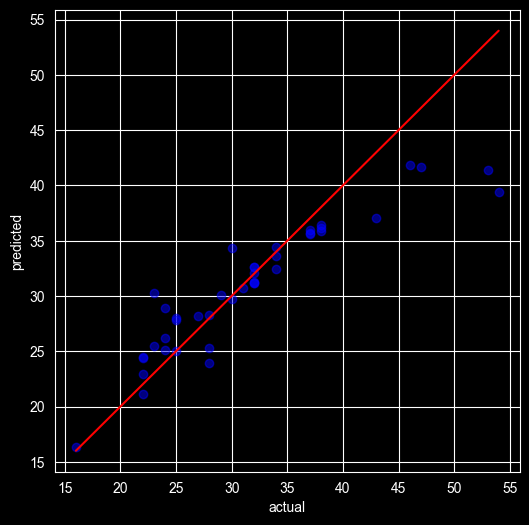

In [28]:
plt.figure(figsize=(6,6))
plt.scatter(Y_test, Y_pred, color = 'blue', alpha=0.5)

min_val = min(Y_test.min(), Y_pred.min())
max_val = max(Y_test.max(), Y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], color = "red")
plt.xlabel("actual")
plt.ylabel("predicted")
plt.show()